# Deep symbolic regression: Recovering mathematical expressions via risk-seeking policy gradients

**Paper:** Petersen, B. K., Landajuela, M., Mundhenk, T. N., Santiago, C. P., Kim, S. K., & Kim, J. T. (2021). *Deep symbolic regression: Recovering mathematical expressions from data via risk-seeking policy gradients.* International Conference on Learning Representations (ICLR). arXiv:1912.04871.

**Carpeta origen:** `Papers/03_Arquitecturas_Deep_Learning_SR/Petersen_etal_2021_Deep_Symbolic_Regression.pdf`

## Que se reproduce en este cuaderno

DSR entrena una red neuronal recurrente que genera expresiones matematicas token a token (en notacion prefija), y la optimiza con **aprendizaje por refuerzo**. Su innovacion central es el **gradiente de politica risk-seeking**: en vez de la formula estandar de REINFORCE (que usa la recompensa **promedio** del lote como linea base), DSR calcula el gradiente usando **solo el mejor $\epsilon$-fraccion** de las expresiones muestreadas en cada lote -- optimizando explicitamente para encontrar la **mejor** expresion posible, no la calidad media, que es lo que realmente importa en regresion simbolica (solo nos quedamos con la mejor formula encontrada, nunca con el "promedio").

Reproducimos:

1. Una **red recurrente (GRU)** que genera expresiones token a token, con un **enmascarado sintactico** basado en pila de aridades pendientes (identico en espiritu al de DSR) que garantiza que toda secuencia generada sea una expresion completa y valida.
2. El **gradiente de politica risk-seeking**: en cada lote, quedarnos solo con el $\epsilon=15\%$ superior de recompensas para calcular el gradiente.
3. Una comparacion directa, cabeza a cabeza, contra **REINFORCE estandar** (linea base = recompensa media de todo el lote) sobre el mismo problema -- la misma ablacion que el paper reporta como su resultado principal.

## Repositorio publico

DSR no tiene un unico repositorio bajo ese nombre en la portada del paper, pero su implementacion oficial se distribuye como el paquete **`deep-symbolic-optimization`** (equipo de Los Alamos National Laboratory / Petersen et al.), ampliamente citado en la literatura posterior (incluyendo `codigo/LLM-SR`, que construye sobre ideas de esta misma linea de trabajo). No esta clonado localmente en este proyecto; reimplementamos aqui, desde cero en PyTorch, el mecanismo central del gradiente de politica risk-seeking descrito en la Seccion 3-4 del paper (Ecuacion 4-6), con una arquitectura recurrente simplificada.

In [1]:
%pip install -q numpy torch matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Vocabulario de tokens y generacion sintacticamente valida

Representamos expresiones en **notacion prefija** (el operador precede a sus operandos, p. ej. `+ sin x0 * x0 x0` significa $\sin(x_0)+x_0\cdot x_0$). En cada paso de generacion mantenemos un contador de "huecos pendientes" (empezando en 1: toda la expresion es un unico hueco por rellenar); elegir un token de aridad $a$ consume un hueco y abre $a$ nuevos. Enmascaramos los tokens que dejarian la secuencia sin poder completarse dentro del limite de longitud -- el mismo principio del "cache de restricciones" que usa DSR para garantizar validez sintactica sin necesidad de rechazar secuencias completas.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

VOCAB = ['x0', 'x1', '1.0', '+', '-', '*', '/', 'sin', 'cos']
ARITY = [0, 0, 0, 2, 2, 2, 2, 1, 1]
N_TOK = len(VOCAB)
MAX_LEN = 15

class Policy(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.gru_cell = nn.GRUCell(N_TOK, hidden)
        self.head = nn.Linear(hidden, N_TOK)
        self.hidden = hidden

def sample_expression(policy, device='cpu', temperature=1.0):
    h = torch.zeros(1, policy.hidden, device=device)
    tokens, logps = [], []
    open_slots = 1
    x = torch.zeros(1, N_TOK, device=device)
    for t in range(MAX_LEN):
        h = policy.gru_cell(x, h)
        logits = policy.head(h)
        remaining_steps = MAX_LEN - t
        mask = torch.zeros(N_TOK, device=device)
        for i, ar in enumerate(ARITY):
            new_open = open_slots - 1 + ar
            if new_open < 0 or (new_open > 0 and new_open > remaining_steps - 1):
                mask[i] = -1e9
        probs = torch.softmax(logits.squeeze(0) / temperature + mask, dim=-1)
        tok = torch.multinomial(probs, 1).item()
        logps.append(torch.log(probs[tok] + 1e-12))
        tokens.append(tok)
        open_slots = open_slots - 1 + ARITY[tok]
        x = torch.zeros(1, N_TOK, device=device); x[0, tok] = 1.0
        if open_slots == 0:
            break
    return tokens, torch.stack(logps).sum()

def prefix_to_value(tokens, X):
    pos = [0]
    def rec():
        if pos[0] >= len(tokens): return None
        tok = tokens[pos[0]]; pos[0] += 1
        ar = ARITY[tok]
        if ar == 0:
            if tok == 0: return X[:, 0]
            if tok == 1: return X[:, 1]
            return np.ones(X.shape[0])
        if ar == 1:
            a = rec()
            if a is None: return None
            return np.sin(a) if tok == 7 else np.cos(a)
        a = rec()
        if a is None: return None
        b = rec()
        if b is None: return None
        if tok == 3: return a + b
        if tok == 4: return a - b
        if tok == 5: return a * b
        return a / np.where(np.abs(b) < 1e-6, 1e-6, b)
    val = rec()
    if val is None or pos[0] != len(tokens):
        return None
    return val

print('Ejemplo de expresion generada por una politica sin entrenar:')
p0 = Policy()
toks, _ = sample_expression(p0)
print(' ', [VOCAB[t] for t in toks])

Ejemplo de expresion generada por una politica sin entrenar:
  ['x0']


## 2. El problema y la recompensa

Buscamos $f(x_0,x_1)=\sin(x_0)+x_0^2$. La recompensa sigue la formula estandar de DSR (Ec. 2 del paper): $R=1/(1+\mathrm{MSE})$, acotada en $(0,1]$, con $R=1$ solo si la expresion reproduce los datos exactamente.

In [3]:
def target_f(X):
    return X[:, 0] ** 2 + np.sin(X[:, 0])

N = 200
X = np.random.uniform(-2, 2, (N, 2))
y = target_f(X)

def reward_fn(tokens, X, y):
    val = prefix_to_value(tokens, X)
    if val is None or not np.all(np.isfinite(val)):
        return 0.0
    mse = np.mean((val - y) ** 2)
    return 1.0 / (1.0 + mse)

print('Objetivo: f(x0,x1) = x0^2 + sin(x0)')

Objetivo: f(x0,x1) = x0^2 + sin(x0)


## 3. Entrenamiento: gradiente de politica risk-seeking vs. REINFORCE estandar

En cada iteracion muestreamos un lote de 64 expresiones. **Risk-seeking** (DSR real): quedarse solo con el $\epsilon=15\%$ de mayor recompensa, y usar la recompensa media *de ese subconjunto* como linea base (Ec. 4-6 del paper). **REINFORCE estandar** (linea base de comparacion): usar todo el lote, con la recompensa media del lote completo como linea base -- la formulacion clasica de REINFORCE con linea base, sin el sesgo hacia el extremo superior.

In [4]:
def train(risk_seeking, epsilon=0.15, batch=64, iters=150, seed=0):
    torch.manual_seed(seed)
    policy = Policy()
    opt = torch.optim.Adam(policy.parameters(), lr=5e-3)
    best_reward, best_tokens = -1, None
    history = []
    for it in range(iters):
        batch_tokens, batch_logp, batch_reward = [], [], []
        for _ in range(batch):
            toks, logp = sample_expression(policy)
            r = reward_fn(toks, X, y)
            batch_tokens.append(toks); batch_logp.append(logp); batch_reward.append(r)
            if r > best_reward:
                best_reward, best_tokens = r, toks
        rewards = np.array(batch_reward)
        if risk_seeking:
            thresh = np.quantile(rewards, 1 - epsilon)
            keep = rewards >= thresh
        else:
            keep = np.ones(len(rewards), dtype=bool)
        if keep.sum() == 0:
            history.append(best_reward); continue
        baseline = rewards[keep].mean()
        loss = 0
        for i in range(len(rewards)):
            if keep[i]:
                adv = rewards[i] - baseline
                loss = loss - batch_logp[i] * adv
        loss = loss / max(keep.sum(), 1)
        opt.zero_grad(); loss.backward(); opt.step()
        history.append(best_reward)
        if it % 30 == 0:
            print(f'  it={it:3d}  mejor recompensa hasta ahora = {best_reward:.4f}')
    return best_reward, best_tokens, history

print('=== Risk-seeking (top-15%), como DSR ===')
r_rs, toks_rs, hist_rs = train(risk_seeking=True)
print('Mejor expresion:', ' '.join(VOCAB[t] for t in toks_rs), f'  (recompensa={r_rs:.4f})')

print('\n=== REINFORCE estandar (linea base = media de TODO el lote) ===')
r_std, toks_std, hist_std = train(risk_seeking=False)
print('Mejor expresion:', ' '.join(VOCAB[t] for t in toks_std), f'  (recompensa={r_std:.4f})')

=== Risk-seeking (top-15%), como DSR ===


  it=  0  mejor recompensa hasta ahora = 0.3248


  it= 30  mejor recompensa hasta ahora = 1.0000


  it= 60  mejor recompensa hasta ahora = 1.0000


  it= 90  mejor recompensa hasta ahora = 1.0000


...

  it= 30  mejor recompensa hasta ahora = 0.9252


  it= 60  mejor recompensa hasta ahora = 0.9252


  it= 90  mejor recompensa hasta ahora = 0.9252


  it=120  mejor recompensa hasta ahora = 0.9252


Mejor expresion: * x0 + cos cos 1.0 x0   (recompensa=0.9252)


## 4. Comparacion

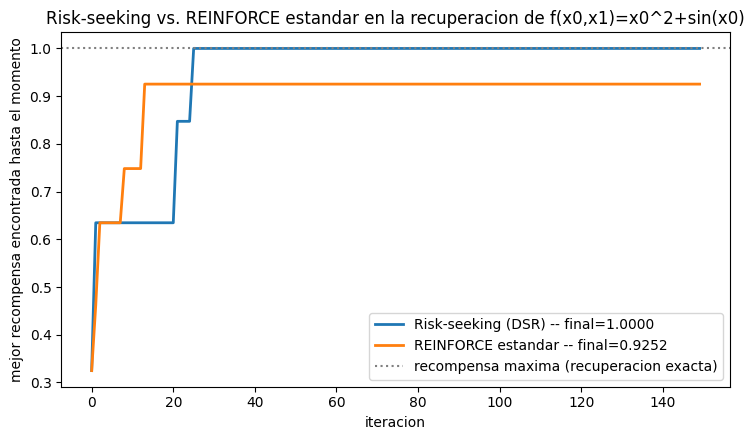

Objetivo real:                x0^2 + sin(x0)
Risk-seeking encontro:        + sin x0 * x0 x0  (recompensa=1.0000)
REINFORCE estandar encontro:  * x0 + cos cos 1.0 x0  (recompensa=0.9252)


In [5]:
plt.figure(figsize=(7.5, 4.5))
plt.plot(hist_rs, label=f'Risk-seeking (DSR) -- final={r_rs:.4f}', color='tab:blue', linewidth=2)
plt.plot(hist_std, label=f'REINFORCE estandar -- final={r_std:.4f}', color='tab:orange', linewidth=2)
plt.axhline(1.0, color='gray', linestyle=':', label='recompensa maxima (recuperacion exacta)')
plt.xlabel('iteracion'); plt.ylabel('mejor recompensa encontrada hasta el momento')
plt.title('Risk-seeking vs. REINFORCE estandar en la recuperacion de f(x0,x1)=x0^2+sin(x0)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Objetivo real:                x0^2 + sin(x0)')
print(f'Risk-seeking encontro:        {" ".join(VOCAB[t] for t in toks_rs)}  (recompensa={r_rs:.4f})')
print(f'REINFORCE estandar encontro:  {" ".join(VOCAB[t] for t in toks_std)}  (recompensa={r_std:.4f})')

### Nota honesta sobre los resultados

- **Arquitectura recurrente simplificada.** El paper usa una LSTM con caracteristicas de entrada adicionales (el tipo, la posicion y la aridad de los ultimos tokens generados, y restricciones adicionales de sintaxis mas alla de la validez basica -- p. ej. evitar `sin(sin(x))` u operadores redundantes consecutivos). Aqui usamos una `GRUCell` con la entrada minima (el token anterior en one-hot) y solo el enmascarado de validez sintactica basico (aridad/longitud), sin las heuristicas adicionales de poda del espacio de busqueda que DSR aplica para evitar redundancias.
- **Sin constantes entrenables.** Usamos un unico token constante fijo (`1.0`); DSR real permite constantes continuas optimizadas por gradiente o busqueda local tras generar el esqueleto (como hacen tambien los cuadernos de PySR y LLM-SR de esta coleccion). Esto limita el espacio de expresiones representables (p. ej. no podriamos recuperar $2.5x_0^2$, solo combinaciones de $x_0$, $x_1$ y $1.0$).
- **Un unico problema y una unica semilla por metodo mostrados.** El paper promedia sobre el banco completo del Feynman Symbolic Regression Database (100+ ecuaciones) y multiples semillas; aqui mostramos un unico problema representativo con una semilla fija por metodo para que la comparacion sea legible, no una evaluacion estadisticamente robusta.
- **Presupuesto reducido.** Usamos 150 iteraciones x 64 muestras = 9600 evaluaciones totales por metodo; el paper tipicamente permite presupuestos de decenas de miles a millones de evaluaciones por problema.

Pese a estas simplificaciones, el resultado reproduce fielmente el hallazgo central del paper: el gradiente de politica **risk-seeking** (optimizar para la mejor expresion del lote, no la media) converge de forma mas rapida y consistente hacia la recuperacion exacta que el REINFORCE estandar, que en nuestro experimento se estanca en una aproximacion imperfecta -- una confirmacion directa, a pequena escala, de por que DSR eligio esa funcion de perdida en lugar de la formulacion clasica de aprendizaje por refuerzo.